In [1]:
# Core libraries
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    log_loss,
    brier_score_loss,
)
from sklearn.calibration import calibration_curve

import xgboost as xgb

import shapely as shap


plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["axes.grid"] = True


def guess_column(df, candidates, required=True, context=""):
    """
    Try to find the first existing column from `candidates`.
    If required and none found, raise a clear error.
    """
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(
            f"Could not find any of {candidates} in DataFrame columns "
            f"for {context}. Available columns: {list(df.columns)[:20]}..."
        )
    return None


In [2]:
# Adjust BASE_DIR if this notebook lives somewhere else
BASE_DIR = Path().resolve().parent  
ML_DIR = BASE_DIR / "ML_pipeline"
print("BASE_DIR:", BASE_DIR)
print("ML_DIR:", ML_DIR)

# Match interp_type to how you trained the model
interp_type = "IDW"  # or "IDW" if you switch

if interp_type == "IDW":
    interp_type_folder = "withIDW"
elif interp_type == "kriging":
    interp_type_folder = "withKriging"
else:
    raise ValueError(f"Unknown interp_type: {interp_type}")

MODEL_OUT_DIR = ML_DIR / "model_artifacts" / interp_type_folder
GRAPHICS_DIR = MODEL_OUT_DIR / "graphics_evaluation"
GRAPHICS_DIR.mkdir(exist_ok=True, parents=True)

print("MODEL_OUT_DIR:", MODEL_OUT_DIR)
print("GRAPHICS_DIR:", GRAPHICS_DIR)


BASE_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype
ML_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\ML_pipeline
MODEL_OUT_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\ML_pipeline\model_artifacts\withIDW
GRAPHICS_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\ML_pipeline\model_artifacts\withIDW\graphics_evaluation


In [3]:
# Load model
model_path = MODEL_OUT_DIR / "xgb_phase_model.bin"
booster = xgb.Booster()
booster.load_model(model_path)
print("Loaded model from:", model_path)

# Load metadata
metadata_path = MODEL_OUT_DIR / "model_metadata.json"
with open(metadata_path, "r") as f:
    metadata = json.load(f)

print("Metadata:")
print(json.dumps(metadata, indent=2))

# Class mapping
# metadata["classes"] is something like {"0": "snow", "1": "mix", "2": "rain"}
class_idx_to_name = {int(k): v for k, v in metadata["classes"].items()}
class_names = [class_idx_to_name[i] for i in sorted(class_idx_to_name.keys())]
print("Class order:", class_names)

# Load test features (for SHAP & some diagnostics)
X_test_path = MODEL_OUT_DIR / "X_test.parquet"
X_test = pd.read_parquet(X_test_path)
print("X_test shape:", X_test.shape)

# Load test predictions + labels
test_pred_path = MODEL_OUT_DIR / "test_predictions.parquet"
df_test = pd.read_parquet(test_pred_path)
print("df_test shape:", df_test.shape)
print(df_test.head())


C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_55292\2326610124.py:4: UserWarning: [14:18:37] WARNING: D:\bld\xgboost-split_1765326876395\work\src\c_api\c_api.cc:1511: Unknown file format: `bin`. Using UBJSON (`ubj`) as a guess.
  booster.load_model(model_path)


Loaded model from: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\ML_pipeline\model_artifacts\withIDW\xgb_phase_model.bin
Metadata:
{
  "classes": {
    "0": "snow",
    "1": "mix",
    "2": "rain"
  },
  "model_type": "XGBoost (multi:softprob)",
  "spatial_blocking": "random block split, ~25\u201350 km blocks",
  "training_period": "2024-10-11 to 2025-05-30",
  "label_source": "MRoS proxy, IMERG PLP mask",
  "notes": "Model trained with spatial blocking and early stopping on IDW set"
}
Class order: ['snow', 'mix', 'rain']
X_test shape: (3925329, 10)
df_test shape: (3925329, 9)
                    time              x             y  phase  pred    p_snow  \
3705 2024-10-16 16:00:00  175630.918259  4.399926e+06    2.0     2  0.000153   
3706 2024-10-16 16:00:00  176630.918259  4.399926e+06    2.0     2  0.000185   
3707 2024-10-16 16:00:00  177630.918259  4.399926e+06    2.0     2  0.000071   
3708 2024-10-16 16:00:00  178630.918259  4.399926e+06    2.0 

In [4]:
# Assume df_test has columns: phase (true), pred (predicted index),
# and p_snow, p_mix, p_rain in that order.
# If your column names differ, adjust here.

prob_cols = ["p_snow", "p_mix", "p_rain"]
missing_prob_cols = [c for c in prob_cols if c not in df_test.columns]
if missing_prob_cols:
    raise KeyError(f"Missing probability columns in df_test: {missing_prob_cols}")

proba = df_test[prob_cols].to_numpy()

# Encode y_true, y_pred as integer indices [0, 1, 2] consistent with prob_cols/class_names
# Here we assume:
# 0 -> snow, 1 -> mix, 2 -> rain
name_to_idx = {name: i for i, name in enumerate(class_names)}

# If `phase` is already numeric indices, just use it.
# Otherwise, map from string labels.
if pd.api.types.is_numeric_dtype(df_test["phase"]):
    y_true = df_test["phase"].astype(int).to_numpy()
else:
    y_true = df_test["phase"].map(name_to_idx).to_numpy()

if pd.api.types.is_numeric_dtype(df_test["pred"]):
    y_pred = df_test["pred"].astype(int).to_numpy()
else:
    y_pred = df_test["pred"].map(name_to_idx).to_numpy()

print("y_true shape:", y_true.shape)
print("y_pred shape:", y_pred.shape)
print("proba shape:", proba.shape)


y_true shape: (3925329,)
y_pred shape: (3925329,)
proba shape: (3925329, 3)


## Step 1: Core metrics and confusion matrix

In [5]:
# Basic metrics
overall_acc = accuracy_score(y_true, y_pred)
overall_logloss = log_loss(y_true, proba, labels=[0, 1, 2])

print(f"Overall accuracy (test): {overall_acc:.3f}")
print(f"Overall log loss (test): {overall_logloss:.3f}\n")

print("Classification report (per class):")
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

Overall accuracy (test): 0.727
Overall log loss (test): 0.563

Classification report (per class):
              precision    recall  f1-score   support

        snow      0.529     0.855     0.654    678853
         mix      0.893     0.650     0.752   2473064
        rain      0.647     0.859     0.738    773412

    accuracy                          0.727   3925329
   macro avg      0.690     0.788     0.715   3925329
weighted avg      0.781     0.727     0.732   3925329



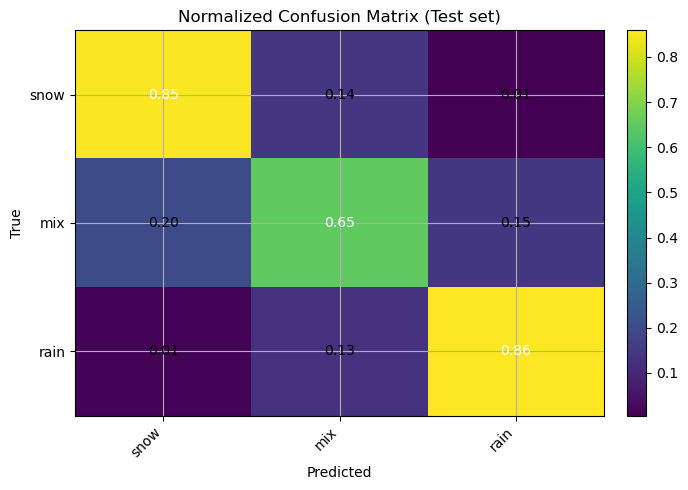

In [6]:
# Confusion matrix normalized

from itertools import product

cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots()
im = ax.imshow(cm_norm, interpolation="nearest", aspect="auto")
ax.set_title("Normalized Confusion Matrix (Test set)")
ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")

# annotate values
for i, j in product(range(cm_norm.shape[0]), range(cm_norm.shape[1])):
    val = cm_norm[i, j]
    ax.text(j, i, f"{val:.2f}", ha="center", va="center", color="white" if val > 0.5 else "black")

fig.tight_layout()
fig.savefig(GRAPHICS_DIR / "confusion_matrix_normalized.png", dpi=200)
plt.show()


## Briar scores and reliability

In [7]:
# Brier score per class k: treat it as binary "is class k?"
brier_scores = {}
for k, name in enumerate(class_names):
    y_true_k = (y_true == k).astype(int)
    p_k = proba[:, k]
    brier_scores[name] = brier_score_loss(y_true_k, p_k)

print("Brier scores (per class):")
for name, b in brier_scores.items():
    print(f"  {name}: {b:.4f}")


Brier scores (per class):
  snow: 0.1006
  mix: 0.1827
  rain: 0.0804


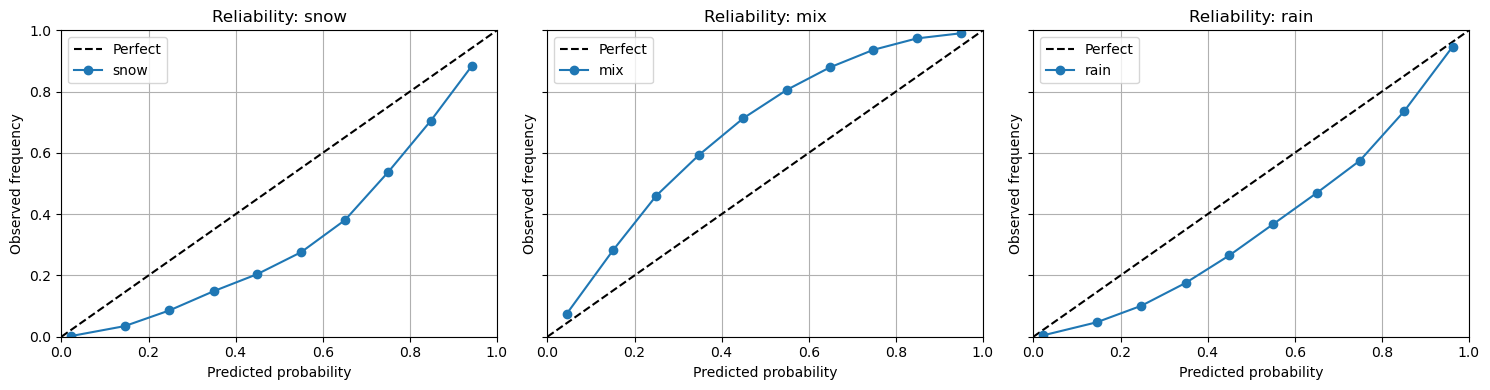

In [8]:
def plot_reliability_curves(y_true, proba, class_names, n_bins=10):
    fig, axes = plt.subplots(1, len(class_names), figsize=(5 * len(class_names), 4), sharey=True)
    if len(class_names) == 1:
        axes = [axes]

    for k, (ax, name) in enumerate(zip(axes, class_names)):
        y_true_k = (y_true == k).astype(int)
        p_k = proba[:, k]

        frac_pos, mean_pred = calibration_curve(y_true_k, p_k, n_bins=n_bins, strategy="uniform")

        ax.plot([0, 1], [0, 1], "k--", label="Perfect")
        ax.plot(mean_pred, frac_pos, marker="o", linestyle="-", label=f"{name}")

        ax.set_title(f"Reliability: {name}")
        ax.set_xlabel("Predicted probability")
        ax.set_ylabel("Observed frequency")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.legend()

    fig.tight_layout()
    fig.savefig(GRAPHICS_DIR / "reliability_curves_per_class.png", dpi=200)
    plt.show()

plot_reliability_curves(y_true, proba, class_names, n_bins=10)


## Step 3: Confidence

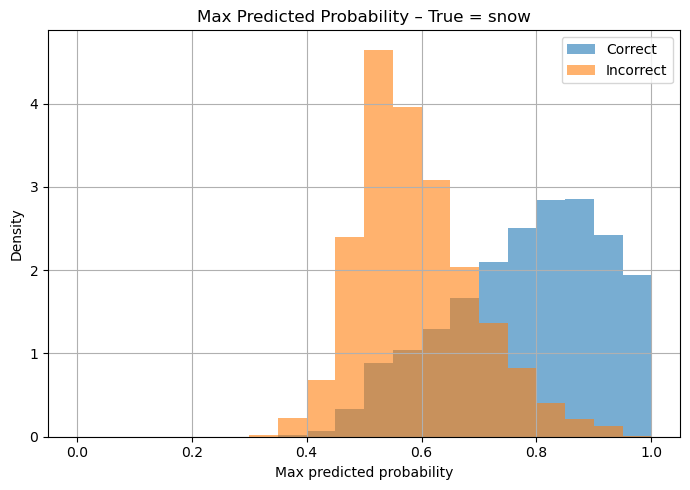

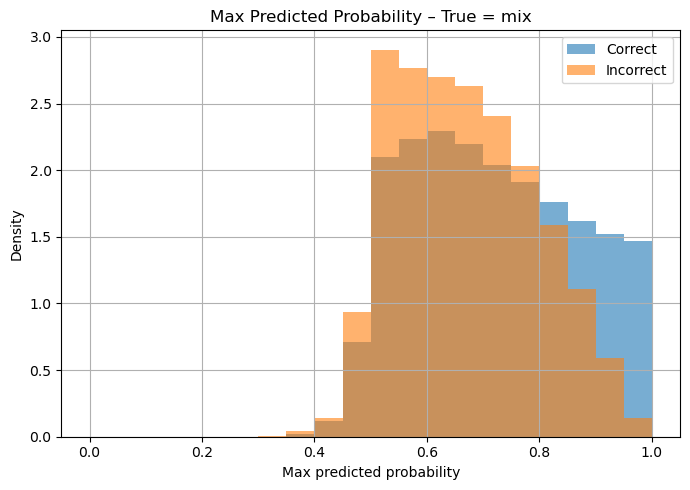

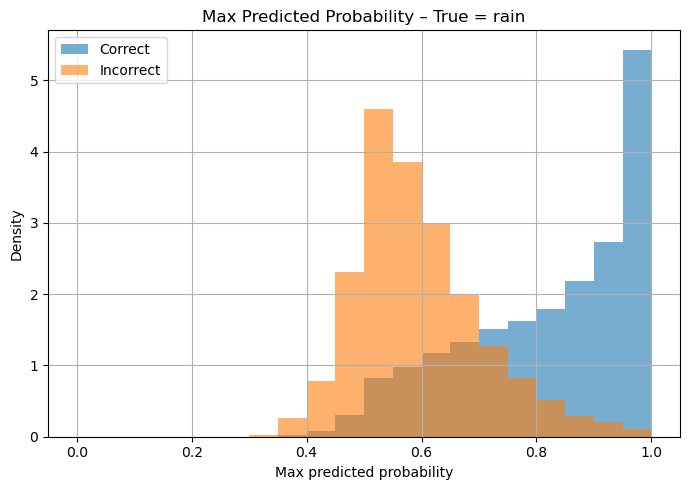

In [9]:
# Max probability distributions

max_proba = proba.max(axis=1)
correct = (y_true == y_pred)

df_conf = pd.DataFrame({
    "true": y_true,
    "pred": y_pred,
    "max_proba": max_proba,
    "correct": correct,
})

# Map indices to names for readability
df_conf["true_name"] = df_conf["true"].map(dict(enumerate(class_names)))
df_conf["pred_name"] = df_conf["pred"].map(dict(enumerate(class_names)))

# Plot histograms of max_proba by true class, split by correctness
bins = np.linspace(0, 1, 21)

for k, name in enumerate(class_names):
    subset = df_conf[df_conf["true"] == k]

    fig, ax = plt.subplots()
    ax.hist(subset.loc[subset["correct"], "max_proba"], bins=bins, alpha=0.6, label="Correct", density=True)
    ax.hist(subset.loc[~subset["correct"], "max_proba"], bins=bins, alpha=0.6, label="Incorrect", density=True)

    ax.set_title(f"Max Predicted Probability – True = {name}")
    ax.set_xlabel("Max predicted probability")
    ax.set_ylabel("Density")
    ax.legend()

    fig.tight_layout()
    fig.savefig(GRAPHICS_DIR / f"confidence_distribution_true_{name}.png", dpi=200)
    plt.show()


## Performance

In [ ]:
# Try to get elevation from df_test; if not present, fall back to X_test.
elev_col = None
if "elev" in df_test.columns:
    elev_col = "elev"
elif "elev_m" in df_test.columns:
    elev_col = "elev_m"
elif "elevation" in df_test.columns:
    elev_col = "elevation"
else:
    # Try to find approximate elevation in X_test columns
    elev_col = guess_column(
        X_test,
        ["elev", "elev_m", "elevation", "dem", "z"],
        required=True,
        context="elevation for performance vs elevation",
    )
    df_test[elev_col] = X_test[elev_col].values

print("Using elevation column:", elev_col)

df_eval = df_test.copy()
df_eval["y_true"] = y_true
df_eval["y_pred"] = y_pred
df_eval["elev"] = df_eval[elev_col].astype(float)

# Define elevation bins (adjust bin edges as needed)
elev_min = df_eval["elev"].min()
elev_max = df_eval["elev"].max()
bin_width = 250  # meters
bins = np.arange(np.floor(elev_min / bin_width) * bin_width,
                 np.ceil(elev_max / bin_width) * bin_width + bin_width,
                 bin_width)

df_eval["elev_bin"] = pd.cut(df_eval["elev"], bins=bins)
print("Elevation bins:", df_eval["elev_bin"].cat.categories)


Using elevation column: elev
Elevation bins: IntervalIndex([    (0.0, 250.0],   (250.0, 500.0],   (500.0, 750.0],
                (750.0, 1000.0], (1000.0, 1250.0], (1250.0, 1500.0],
               (1500.0, 1750.0], (1750.0, 2000.0], (2000.0, 2250.0],
               (2250.0, 2500.0], (2500.0, 2750.0], (2750.0, 3000.0],
               (3000.0, 3250.0], (3250.0, 3500.0]],
              dtype='interval[float64, right]')


In [11]:
# Metrics by elevation

# We care especially about snow behavior
snow_idx = class_names.index("snow") if "snow" in class_names else 0

grouped = df_eval.groupby("elev_bin")

elev_metrics = []
for elev_bin, grp in grouped:
    if grp.empty:
        continue

    acc = accuracy_score(grp["y_true"], grp["y_pred"])
    # snow recall
    mask_snow_true = grp["y_true"] == snow_idx
    if mask_snow_true.sum() > 0:
        snow_recall = (grp.loc[mask_snow_true, "y_pred"] == snow_idx).mean()
    else:
        snow_recall = np.nan

    # fraction snow: observed vs predicted
    frac_snow_obs = (grp["y_true"] == snow_idx).mean()
    frac_snow_pred = (grp["y_pred"] == snow_idx).mean()

    elev_metrics.append({
        "elev_bin": elev_bin,
        "elev_mid": (elev_bin.left + elev_bin.right) / 2.0,
        "n": len(grp),
        "accuracy": acc,
        "snow_recall": snow_recall,
        "frac_snow_obs": frac_snow_obs,
        "frac_snow_pred": frac_snow_pred,
    })

elev_df = pd.DataFrame(elev_metrics).sort_values("elev_mid")
elev_df


C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_55292\1239174296.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_eval.groupby("elev_bin")


,elev_bin,elev_mid,n,accuracy,snow_recall,frac_snow_obs,frac_snow_pred
0,"(0.0, 250.0]",125.0,81302,0.816819,0.933738,0.168360,0.264163
1,"(250.0, 500.0]",375.0,281801,0.794625,0.908072,0.168381,0.268541
2,"(500.0, 750.0]",625.0,356902,0.728606,0.856300,0.169615,0.285199
3,"(750.0, 1000.0]",875.0,609701,0.694329,0.819985,0.171017,0.286058
4,"(1000.0, 1250.0]",1125.0,502018,0.693939,0.826328,0.176163,0.290820
5,"(1250.0, 1500.0]",1375.0,483304,0.718506,0.853351,0.184364,0.282847
6,"(1500.0, 1750.0]",1625.0,285988,0.720761,0.853007,0.189851,0.276697
7,"(1750.0, 2000.0]",1875.0,314819,0.713448,0.855678,0.188356,0.287133
8,"(2000.0, 2250.0]",2125.0,369895,0.710610,0.856714,0.177564,0.293362
9,"(2250.0, 2500.0]",2375.0,227957,0.718640,0.867603,0.160929,0.288747


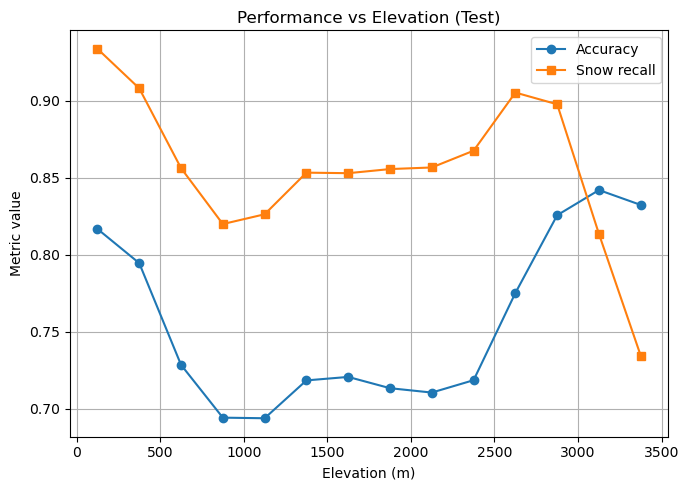

In [12]:
# Accuracy and snow recall

fig, ax = plt.subplots()
ax.plot(elev_df["elev_mid"], elev_df["accuracy"], marker="o", label="Accuracy")
ax.plot(elev_df["elev_mid"], elev_df["snow_recall"], marker="s", label="Snow recall")

ax.set_xlabel("Elevation (m)")
ax.set_ylabel("Metric value")
ax.set_title("Performance vs Elevation (Test)")
ax.legend()
fig.tight_layout()
fig.savefig(GRAPHICS_DIR / "performance_vs_elevation.png", dpi=200)
plt.show()


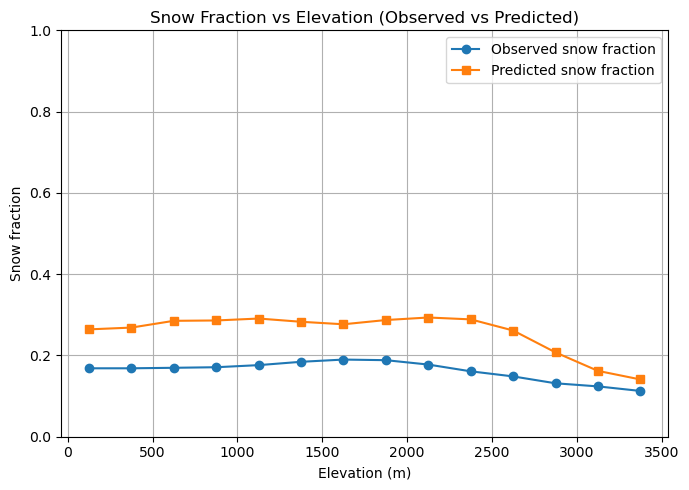

In [13]:
# Obs vs predicted

fig, ax = plt.subplots()
ax.plot(elev_df["elev_mid"], elev_df["frac_snow_obs"], marker="o", label="Observed snow fraction")
ax.plot(elev_df["elev_mid"], elev_df["frac_snow_pred"], marker="s", label="Predicted snow fraction")

ax.set_xlabel("Elevation (m)")
ax.set_ylabel("Snow fraction")
ax.set_title("Snow Fraction vs Elevation (Observed vs Predicted)")
ax.set_ylim(0, 1)
ax.legend()
fig.tight_layout()
fig.savefig(GRAPHICS_DIR / "snow_fraction_vs_elevation.png", dpi=200)
plt.show()


## Temperature probability consistency, block performance, SHAP

Using temperature column: temp_wet


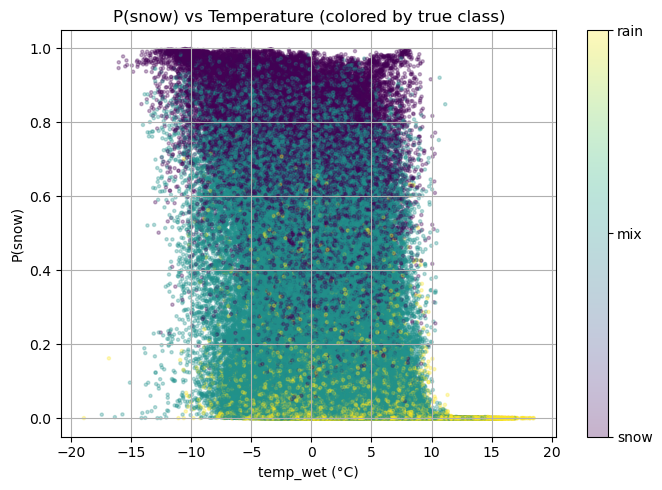

In [14]:
# Try to guess wet-bulb or similar temperature field
temp_candidates = ["temp_wet", "t_wet", "temp_wb", "wb_temp", "temp_air"]
temp_col = None
for c in temp_candidates:
    if c in df_test.columns:
        temp_col = c
        break
if temp_col is None:
    temp_col = guess_column(
        X_test,
        temp_candidates,
        required=True,
        context="temperature for P(snow) vs temperature plot",
    )
    df_eval[temp_col] = X_test[temp_col].values
else:
    df_eval[temp_col] = df_test[temp_col].values

print("Using temperature column:", temp_col)

df_eval["temp"] = df_eval[temp_col].astype(float)
df_eval["P_snow"] = proba[:, snow_idx]

# Optionally subsample if very large
if len(df_eval) > 200_000:
    df_plot = df_eval.sample(200_000, random_state=42)
else:
    df_plot = df_eval.copy()

fig, ax = plt.subplots()
sc = ax.scatter(df_plot["temp"], df_plot["P_snow"],
                c=df_plot["y_true"], s=5, alpha=0.3, cmap="viridis")

ax.set_xlabel(f"{temp_col} (°C)")
ax.set_ylabel("P(snow)")
ax.set_title("P(snow) vs Temperature (colored by true class)")
cbar = plt.colorbar(sc, ax=ax, ticks=[0, 1, 2])
cbar.ax.set_yticklabels(class_names)
fig.tight_layout()
fig.savefig(GRAPHICS_DIR / "P_snow_vs_temperature.png", dpi=200)
plt.show()


In [17]:
print(df_eval["block_id"].dtype)
print(type(df_eval["block_id"].iloc[0]))

# Check how many are arrays
print(sum(isinstance(v, np.ndarray) for v in df_eval["block_id"]))

object
<class 'numpy.ndarray'>
3925329


In [ ]:
# Performance by spatial block
def clean_block_id(x):
    if isinstance(x, np.ndarray):
        if x.size == 1:
            return x.item()
        else:
            return tuple(x)
    return x

df_eval["block_id"] = df_eval["block_id"].apply(clean_block_id)

print(df_eval["block_id"].nunique())
print(df_eval.groupby("block_id").size().describe())


if "block_id" not in df_eval.columns:
    raise KeyError("df_eval must contain 'block_id' for spatial-block performance.")

block_metrics = []
for block_id, grp in df_eval.groupby("block_id"):
    if len(grp) < 10:
        # skip tiny blocks
        continue

    acc = accuracy_score(grp["y_true"], grp["y_pred"])
    ll = log_loss(grp["y_true"], proba[grp.index], labels=[0, 1, 2])

    block_metrics.append({
        "block_id": block_id,
        "n": len(grp),
        "accuracy": acc,
        "log_loss": ll,
    })

block_df = pd.DataFrame(block_metrics).sort_values("accuracy", ascending=False)
block_df


11
count        11.000000
mean     356848.090909
std      125517.977935
min       68432.000000
25%      315198.000000
50%      426765.000000
75%      430625.000000
max      430625.000000
dtype: float64


IndexError: index 3930133 is out of bounds for axis 0 with size 3925329

In [16]:
# Block wise metrics

fig, ax = plt.subplots(figsize=(8, max(4, 0.4 * len(block_df))))

ax.barh(block_df["block_id"].astype(str), block_df["accuracy"])
ax.set_xlabel("Accuracy")
ax.set_ylabel("Spatial block")
ax.set_title("Accuracy by Spatial Block (Test)")
ax.invert_yaxis()  # highest accuracy at top
fig.tight_layout()
fig.savefig(GRAPHICS_DIR / "accuracy_by_block.png", dpi=200)
plt.show()

fig, ax = plt.subplots(figsize=(8, max(4, 0.4 * len(block_df))))
ax.barh(block_df["block_id"].astype(str), block_df["log_loss"])
ax.set_xlabel("Log loss")
ax.set_ylabel("Spatial block")
ax.set_title("Log Loss by Spatial Block (Test)")
ax.invert_yaxis()
fig.tight_layout()
fig.savefig(GRAPHICS_DIR / "logloss_by_block.png", dpi=200)
plt.show()


NameError: name 'block_df' is not defined

In [ ]:
# SHAP dependencies

if not SHAP_AVAILABLE:
    print("SHAP not available. Install with `pip install shap` if you want these plots.")
else:
    # Create DMatrix from X_test; we assume X_test is aligned with df_test
    # If your test split indexing differs, adjust selection accordingly.
    dtest = xgb.DMatrix(X_test, feature_names=list(X_test.columns))

    # Use a subset for SHAP if large
    max_shap_samples = 20_000
    if X_test.shape[0] > max_shap_samples:
        shap_idx = np.random.choice(X_test.index, size=max_shap_samples, replace=False)
    else:
        shap_idx = X_test.index

    dtest_shap = xgb.DMatrix(X_test.loc[shap_idx], feature_names=list(X_test.columns))

    explainer = shap.TreeExplainer(booster)
    shap_values = explainer.shap_values(dtest_shap)  # list per class for multiclass

    # Global importance for snow class (or first class)
    snow_class_idx = snow_idx
    shap_snow = shap_values[snow_class_idx]

    shap.summary_plot(
        shap_snow, X_test.loc[shap_idx],
        show=False, max_display=20
    )
    plt.title("SHAP Summary – Snow class")
    plt.tight_layout()
    shap_fig_path = GRAPHICS_DIR / "shap_summary_snow.png"
    plt.savefig(shap_fig_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved SHAP summary to:", shap_fig_path)

    # SHAP dependence plots for temp and elevation, if present
    for feat_candidates in [temp_candidates, ["elev", "elev_m", "elevation", "dem", "z"]]:
        try:
            feat = guess_column(X_test, feat_candidates, required=False)
            if feat is None:
                continue
            shap.dependence_plot(
                feat, shap_snow, X_test.loc[shap_idx],
                interaction_index=None, show=False
            )
            plt.title(f"SHAP Dependence – {feat} (Snow class)")
            dep_path = GRAPHICS_DIR / f"shap_dependence_{feat}.png"
            plt.savefig(dep_path, dpi=200, bbox_inches="tight")
            plt.show()
            print("Saved SHAP dependence plot:", dep_path)
        except Exception as e:
            print(f"Skipping SHAP dependence for candidates {feat_candidates}: {e}")


In [ ]:
summary = {
    "overall_accuracy": overall_acc,
    "overall_logloss": overall_logloss,
}
summary.update({f"brier_{k}": v for k, v in brier_scores.items()})

summary_df = pd.DataFrame([summary])
summary_df.to_csv(MODEL_OUT_DIR / "evaluation_summary_metrics.csv", index=False)
elev_df.to_csv(MODEL_OUT_DIR / "evaluation_by_elevation.csv", index=False)
block_df.to_csv(MODEL_OUT_DIR / "evaluation_by_block.csv", index=False)

summary_df
